# Cuaderno 14 adaptado

## Evaluación responsable de un prototipo multimodal para patrones textiles andinos generados

Este cuaderno adapta la estructura experimental del Cuaderno 14 del curso MCC225. El objetivo es evaluar una tarea de recuperación imagen texto usando imágenes generadas y descripciones textuales controladas.

La evaluación se limita a un escenario académico controlado. Los resultados no deben interpretarse como reconocimiento confiable ni clasificación real de objetos culturales.

In [1]:
# ============================================================
# 1. Imports y configuración general
# ============================================================

from pathlib import Path
import random
import json

import numpy as np
import pandas as pd
from PIL import Image

import torch
import open_clip

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 225
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BASE_DIR = Path("..").resolve()
DATA_DIR = BASE_DIR / "data"
IMAGE_DIR = DATA_DIR / "images"
RESULTS_DIR = BASE_DIR / "results"
FIGURES_DIR = BASE_DIR / "figures"

MANIFEST_PATH = DATA_DIR / "manifest_textiles_generados.csv"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Dispositivo:", DEVICE)
print("Directorio base:", BASE_DIR)
print("Manifiesto:", MANIFEST_PATH)

d:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-albef-textiles-andinos\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dispositivo: cpu
Directorio base: D:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-textiles-generados-evaluacion-multimodal
Manifiesto: D:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-textiles-generados-evaluacion-multimodal\data\manifest_textiles_generados.csv


In [12]:
# ============================================================
# 2. Carga del manifiesto
# ============================================================

manifest = pd.read_csv(MANIFEST_PATH)

print("Filas:", len(manifest))
print("Columnas:", list(manifest.columns))

manifest.head()

Filas: 40
Columnas: ['image_id', 'image_path', 'caption_1', 'caption_2', 'caption_3', 'caption_4', 'caption_5', 'paleta', 'composicion', 'motivo', 'simetria', 'nivel_ambiguedad', 'observacion']


,image_id,image_path,caption_1,caption_2,caption_3,caption_4,caption_5,paleta,composicion,motivo,simetria,nivel_ambiguedad,observacion
0,T001,data/images/T001.png,Patron textil generado con composicion horizon...,Imagen generada de inspiracion textil con band...,"Diseno geometrico generado con paleta rojo, ne...",Patron sintetico con elementos de bandas geome...,Imagen de patron ornamental generado con rasgo...,rojo_negro_crema,horizontal,bandas geometricas,repetitiva,bajo,Imagen generada por script para evaluacion aca...
1,T002,data/images/T002.png,Patron textil generado con composicion vertica...,Imagen generada de inspiracion textil con band...,"Diseno geometrico generado con paleta azul, cr...",Patron sintetico con elementos de bandas geome...,Imagen de patron ornamental generado con rasgo...,azul_crema_marron,vertical,bandas geometricas,repetitiva,bajo,Imagen generada por script para evaluacion aca...
2,T003,data/images/T003.png,Patron textil generado con composicion central...,Imagen generada de inspiracion textil con romb...,"Diseno geometrico generado con paleta ocre, ma...","Patron sintetico con elementos de rombos, dist...",Imagen de patron ornamental generado con rasgo...,ocre_marron_negro,central,rombos,bilateral,medio,Imagen generada por script para evaluacion aca...
3,T004,data/images/T004.png,Patron textil generado con composicion modular...,Imagen generada de inspiracion textil con grec...,"Diseno geometrico generado con paleta blanco, ...",Patron sintetico con elementos de grecas escal...,Imagen de patron ornamental generado con rasgo...,blanco_negro_gris,modular,grecas escalonadas,repetitiva,medio,Imagen generada por script para evaluacion aca...
4,T005,data/images/T005.png,Patron textil generado con composicion reticul...,Imagen generada de inspiracion textil con cuad...,Diseno geometrico generado con paleta multicol...,Patron sintetico con elementos de cuadricula g...,Imagen de patron ornamental generado con rasgo...,multicolor_tierra,reticular,cuadricula geometrica,repetitiva,bajo,Imagen generada por script para evaluacion aca...


In [13]:
# ============================================================
# 3. Validación básica del dataset
# ============================================================

required_columns = [
    "image_id",
    "image_path",
    "caption_1",
    "caption_2",
    "caption_3",
    "caption_4",
    "caption_5",
    "paleta",
    "composicion",
    "motivo",
    "simetria",
    "nivel_ambiguedad",
    "observacion"
]

missing_columns = [col for col in required_columns if col not in manifest.columns]

if missing_columns:
    raise ValueError(f"Faltan columnas en el manifiesto: {missing_columns}")

missing_images = []

for _, row in manifest.iterrows():
    image_path = BASE_DIR / row["image_path"]
    if not image_path.exists():
        missing_images.append(str(image_path))

print("Imágenes esperadas:", len(manifest))
print("Imágenes faltantes:", len(missing_images))

if missing_images:
    print("Primeras imágenes faltantes:")
    for path in missing_images[:5]:
        print(path)
else:
    print("Todas las imágenes existen.")

Imágenes esperadas: 40
Imágenes faltantes: 0
Todas las imágenes existen.


In [14]:
# ============================================================
# 4. Construcción de textos candidatos
# ============================================================

caption_columns = ["caption_1", "caption_2", "caption_3", "caption_4", "caption_5"]

text_rows = []

for _, row in manifest.iterrows():
    for caption_col in caption_columns:
        text_rows.append({
            "text_id": f"{row['image_id']}_{caption_col}",
            "image_id": row["image_id"],
            "caption_col": caption_col,
            "text": row[caption_col]
        })

texts_df = pd.DataFrame(text_rows)

print("Número de imágenes:", manifest["image_id"].nunique())
print("Número de textos candidatos:", len(texts_df))

texts_df.head()

Número de imágenes: 40
Número de textos candidatos: 200


,text_id,image_id,caption_col,text
0,T001_caption_1,T001,caption_1,Patron textil generado con composicion horizon...
1,T001_caption_2,T001,caption_2,Imagen generada de inspiracion textil con band...
2,T001_caption_3,T001,caption_3,"Diseno geometrico generado con paleta rojo, ne..."
3,T001_caption_4,T001,caption_4,Patron sintetico con elementos de bandas geome...
4,T001_caption_5,T001,caption_5,Imagen de patron ornamental generado con rasgo...


In [15]:
# ============================================================
# 5. Carga del modelo OpenCLIP
# ============================================================

MODEL_NAME = "ViT-B-32"
PRETRAINED = "laion2b_s34b_b79k"

model, _, preprocess = open_clip.create_model_and_transforms(
    MODEL_NAME,
    pretrained=PRETRAINED
)

tokenizer = open_clip.get_tokenizer(MODEL_NAME)

model = model.to(DEVICE)
model.eval()

print("Modelo:", MODEL_NAME)
print("Pesos:", PRETRAINED)
print("Dispositivo:", DEVICE)

Modelo: ViT-B-32
Pesos: laion2b_s34b_b79k
Dispositivo: cpu


In [17]:
# ============================================================
# 6. Función auxiliar para cargar imágenes
# ============================================================

def load_image_tensor(image_path):
    image = Image.open(image_path).convert("RGB")
    image_tensor = preprocess(image)
    return image_tensor

In [18]:
# ============================================================
# 7. Cálculo de embeddings de imágenes
# ============================================================

image_tensors = []

for _, row in tqdm(manifest.iterrows(), total=len(manifest)):
    image_path = BASE_DIR / row["image_path"]
    image_tensor = load_image_tensor(image_path)
    image_tensors.append(image_tensor)

image_batch = torch.stack(image_tensors).to(DEVICE)

with torch.no_grad():
    image_features = model.encode_image(image_batch)
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)

print("Embeddings de imágenes:", image_features.shape)

100%|██████████| 40/40 [00:00<00:00, 70.41it/s]


Embeddings de imágenes: torch.Size([40, 512])


In [22]:
# ============================================================
# 8. Cálculo de embeddings de textos
# ============================================================

texts = texts_df["text"].tolist()
text_features_list = []

BATCH_SIZE = 64

with torch.no_grad():
    for start in tqdm(range(0, len(texts), BATCH_SIZE)):
        batch_texts = texts[start:start + BATCH_SIZE]
        tokens = tokenizer(batch_texts).to(DEVICE)
        text_features = model.encode_text(tokens)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)
        text_features_list.append(text_features.cpu())

text_features = torch.cat(text_features_list, dim=0).to(DEVICE)

print("Embeddings de textos:", text_features.shape)

100%|██████████| 4/4 [00:08<00:00,  2.21s/it]

Embeddings de textos: torch.Size([200, 512])


In [23]:
# ============================================================
# 9. Matriz de similitud imagen texto
# ============================================================

with torch.no_grad():
    similarity = image_features @ text_features.T

similarity_np = similarity.cpu().numpy()

print("Matriz de similitud:", similarity_np.shape)

Matriz de similitud: (40, 200)


In [24]:
# ============================================================
# 10. Ranking imagen texto
# ============================================================

rank_rows = []

for image_idx, row in manifest.reset_index(drop=True).iterrows():
    image_id = row["image_id"]
    scores = similarity_np[image_idx]

    sorted_indices = np.argsort(scores)[::-1]

    for rank_position, text_idx in enumerate(sorted_indices[:10], start=1):
        candidate = texts_df.iloc[text_idx]
        rank_rows.append({
            "image_id": image_id,
            "rank": rank_position,
            "text_id": candidate["text_id"],
            "candidate_image_id": candidate["image_id"],
            "caption_col": candidate["caption_col"],
            "caption": candidate["text"],
            "score": float(scores[text_idx]),
            "is_correct": candidate["image_id"] == image_id
        })

rankings_df = pd.DataFrame(rank_rows)

rankings_path = RESULTS_DIR / "rankings_imagen_texto_top10.csv"
rankings_df.to_csv(rankings_path, index=False, encoding="utf-8")

print("Ranking exportado a:", rankings_path)
rankings_df.head(10)

Ranking exportado a: D:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-textiles-generados-evaluacion-multimodal\results\rankings_imagen_texto_top10.csv


,image_id,rank,text_id,candidate_image_id,caption_col,caption,score,is_correct
0,T001,1,T031_caption_1,T031,caption_1,Patron textil generado con composicion horizon...,0.361577,False
1,T001,2,T001_caption_1,T001,caption_1,Patron textil generado con composicion horizon...,0.361577,True
2,T001,3,T013_caption_1,T013,caption_1,Patron textil generado con composicion horizon...,0.354159,False
3,T001,4,T026_caption_1,T026,caption_1,Patron textil generado con composicion vertica...,0.345599,False
4,T001,5,T008_caption_1,T008,caption_1,Patron textil generado con composicion vertica...,0.338024,False
5,T001,6,T038_caption_1,T038,caption_1,Patron textil generado con composicion vertica...,0.338024,False
6,T001,7,T031_caption_3,T031,caption_3,"Diseno geometrico generado con paleta rojo, ne...",0.321843,False
7,T001,8,T001_caption_3,T001,caption_3,"Diseno geometrico generado con paleta rojo, ne...",0.321843,True
8,T001,9,T025_caption_1,T025,caption_1,Patron textil generado con composicion horizon...,0.318969,False
9,T001,10,T006_caption_1,T006,caption_1,"Patron textil generado con composicion mixta, ...",0.316615,False


In [25]:
# ============================================================
# 11. Métricas de recuperación imagen texto
# ============================================================

def compute_retrieval_metrics(similarity_matrix, image_ids, text_image_ids, ks=(1, 5, 10)):
    metrics = {}

    first_correct_ranks = []

    for i, image_id in enumerate(image_ids):
        scores = similarity_matrix[i]
        sorted_indices = np.argsort(scores)[::-1]

        correct_positions = [
            rank + 1
            for rank, idx in enumerate(sorted_indices)
            if text_image_ids[idx] == image_id
        ]

        first_rank = min(correct_positions)
        first_correct_ranks.append(first_rank)

    first_correct_ranks = np.array(first_correct_ranks)

    for k in ks:
        metrics[f"Recall@{k}"] = float(np.mean(first_correct_ranks <= k))

    metrics["MRR"] = float(np.mean(1.0 / first_correct_ranks))
    metrics["rank_promedio_correcto"] = float(np.mean(first_correct_ranks))

    return metrics, first_correct_ranks


image_ids = manifest["image_id"].tolist()
text_image_ids = texts_df["image_id"].tolist()

model_metrics, first_correct_ranks = compute_retrieval_metrics(
    similarity_np,
    image_ids,
    text_image_ids,
    ks=(1, 5, 10)
)

model_metrics

{'Recall@1': 0.325,
 'Recall@5': 0.6,
 'Recall@10': 0.85,
 'MRR': 0.4812562240391188,
 'rank_promedio_correcto': 5.45}

In [26]:
# ============================================================
# 12. Baseline aleatorio
# ============================================================

def random_baseline_metrics(image_ids, text_image_ids, n_runs=1000, ks=(1, 5, 10)):
    rng = np.random.default_rng(SEED)
    n_texts = len(text_image_ids)

    run_metrics = []

    for _ in range(n_runs):
        fake_similarity = rng.random((len(image_ids), n_texts))
        metrics, _ = compute_retrieval_metrics(
            fake_similarity,
            image_ids,
            text_image_ids,
            ks=ks
        )
        run_metrics.append(metrics)

    baseline = {}

    for key in run_metrics[0].keys():
        values = [m[key] for m in run_metrics]
        baseline[key] = float(np.mean(values))

    return baseline


baseline_metrics = random_baseline_metrics(
    image_ids=image_ids,
    text_image_ids=text_image_ids,
    n_runs=1000,
    ks=(1, 5, 10)
)

baseline_metrics

{'Recall@1': 0.026175000000000004,
 'Recall@5': 0.1193,
 'Recall@10': 0.22542500000000001,
 'MRR': 0.09703543051711043,
 'rank_promedio_correcto': 33.8198}

In [27]:
# ============================================================
# 13. Exportación de métricas
# ============================================================

metrics_rows = []

for metric_name, value in model_metrics.items():
    metrics_rows.append({
        "experimento": "E1",
        "modelo": f"OpenCLIP {MODEL_NAME}",
        "direccion": "imagen_texto",
        "numero_imagenes": len(manifest),
        "numero_textos": len(texts_df),
        "metrica": metric_name,
        "resultado": value,
        "interpretacion": "Resultado del modelo en recuperación imagen texto"
    })

for metric_name, value in baseline_metrics.items():
    metrics_rows.append({
        "experimento": "E2",
        "modelo": "baseline_aleatorio",
        "direccion": "imagen_texto",
        "numero_imagenes": len(manifest),
        "numero_textos": len(texts_df),
        "metrica": metric_name,
        "resultado": value,
        "interpretacion": "Resultado promedio de un ranking aleatorio"
    })

metrics_df = pd.DataFrame(metrics_rows)

metrics_path = RESULTS_DIR / "metricas.csv"
metrics_df.to_csv(metrics_path, index=False, encoding="utf-8")

print("Métricas exportadas a:", metrics_path)
metrics_df

Métricas exportadas a: D:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-textiles-generados-evaluacion-multimodal\results\metricas.csv


,experimento,modelo,direccion,numero_imagenes,numero_textos,metrica,resultado,interpretacion
0,E1,OpenCLIP ViT-B-32,imagen_texto,40,200,Recall@1,0.325000,Resultado del modelo en recuperación imagen texto
1,E1,OpenCLIP ViT-B-32,imagen_texto,40,200,Recall@5,0.600000,Resultado del modelo en recuperación imagen texto
2,E1,OpenCLIP ViT-B-32,imagen_texto,40,200,Recall@10,0.850000,Resultado del modelo en recuperación imagen texto
3,E1,OpenCLIP ViT-B-32,imagen_texto,40,200,MRR,0.481256,Resultado del modelo en recuperación imagen texto
4,E1,OpenCLIP ViT-B-32,imagen_texto,40,200,rank_promedio_correcto,5.450000,Resultado del modelo en recuperación imagen texto
5,E2,baseline_aleatorio,imagen_texto,40,200,Recall@1,0.026175,Resultado promedio de un ranking aleatorio
6,E2,baseline_aleatorio,imagen_texto,40,200,Recall@5,0.119300,Resultado promedio de un ranking aleatorio
7,E2,baseline_aleatorio,imagen_texto,40,200,Recall@10,0.225425,Resultado promedio de un ranking aleatorio
8,E2,baseline_aleatorio,imagen_texto,40,200,MRR,0.097035,Resultado promedio de un ranking aleatorio
9,E2,baseline_aleatorio,imagen_texto,40,200,rank_promedio_correcto,33.819800,Resultado promedio de un ranking aleatorio


In [28]:
# ============================================================
# 14. Tabla de primer acierto por imagen
# ============================================================

first_rank_rows = []

for image_idx, row in manifest.reset_index(drop=True).iterrows():
    image_id = row["image_id"]
    scores = similarity_np[image_idx]
    sorted_indices = np.argsort(scores)[::-1]

    first_correct_rank = None
    first_correct_caption = None
    first_correct_score = None

    top1_idx = sorted_indices[0]
    top1_candidate = texts_df.iloc[top1_idx]

    for rank_position, text_idx in enumerate(sorted_indices, start=1):
        candidate = texts_df.iloc[text_idx]
        if candidate["image_id"] == image_id:
            first_correct_rank = rank_position
            first_correct_caption = candidate["text"]
            first_correct_score = float(scores[text_idx])
            break

    first_rank_rows.append({
        "image_id": image_id,
        "top1_text_id": top1_candidate["text_id"],
        "top1_image_id": top1_candidate["image_id"],
        "top1_caption": top1_candidate["text"],
        "top1_score": float(scores[top1_idx]),
        "is_top1_correct": top1_candidate["image_id"] == image_id,
        "first_correct_rank": first_correct_rank,
        "first_correct_caption": first_correct_caption,
        "first_correct_score": first_correct_score
    })

first_rank_df = pd.DataFrame(first_rank_rows)

first_rank_path = RESULTS_DIR / "primer_acierto_por_imagen.csv"
first_rank_df.to_csv(first_rank_path, index=False, encoding="utf-8")

print("Tabla exportada a:", first_rank_path)
first_rank_df.head()

Tabla exportada a: D:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-textiles-generados-evaluacion-multimodal\results\primer_acierto_por_imagen.csv


,image_id,top1_text_id,top1_image_id,top1_caption,top1_score,is_top1_correct,first_correct_rank,first_correct_caption,first_correct_score
0,T001,T031_caption_1,T031,Patron textil generado con composicion horizon...,0.361577,False,2,Patron textil generado con composicion horizon...,0.361577
1,T002,T032_caption_1,T032,Patron textil generado con composicion vertica...,0.369598,False,2,Patron textil generado con composicion vertica...,0.369598
2,T003,T033_caption_1,T033,Patron textil generado con composicion central...,0.284346,False,2,Patron textil generado con composicion central...,0.284346
3,T004,T014_caption_1,T014,Patron textil generado con composicion vertica...,0.307225,False,8,Patron textil generado con composicion modular...,0.277815
4,T005,T020_caption_1,T020,Patron textil generado con composicion vertica...,0.272386,False,5,Patron textil generado con composicion reticul...,0.265400


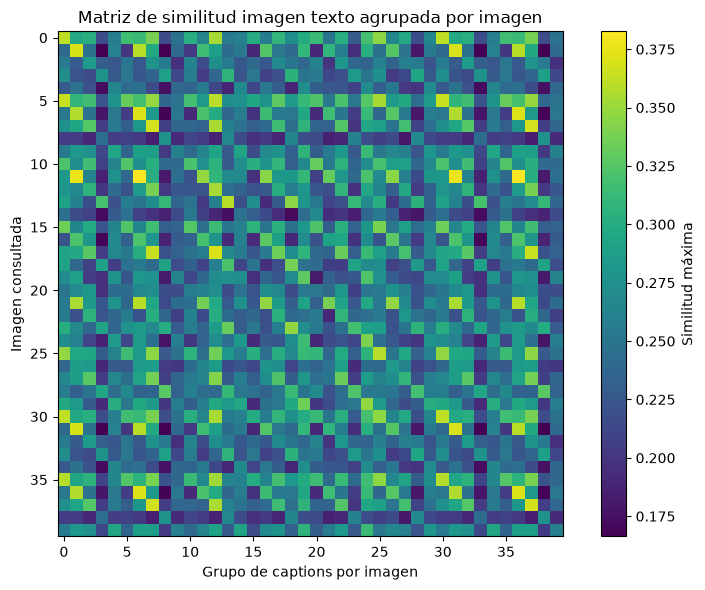

Figura guardada en: D:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-textiles-generados-evaluacion-multimodal\figures\matriz_similitud_agrupada.png


In [29]:
# ============================================================
# 15. Matriz de similitud imagen contra grupo de captions
# ============================================================

image_to_group_scores = []

for image_idx, image_id in enumerate(image_ids):
    row_scores = []

    for target_image_id in image_ids:
        text_indices = texts_df.index[texts_df["image_id"] == target_image_id].tolist()
        max_score = similarity_np[image_idx, text_indices].max()
        row_scores.append(max_score)

    image_to_group_scores.append(row_scores)

image_to_group_scores = np.array(image_to_group_scores)

plt.figure(figsize=(8, 6))
plt.imshow(image_to_group_scores)
plt.colorbar(label="Similitud máxima")
plt.title("Matriz de similitud imagen texto agrupada por imagen")
plt.xlabel("Grupo de captions por imagen")
plt.ylabel("Imagen consultada")
plt.tight_layout()

matrix_path = FIGURES_DIR / "matriz_similitud_agrupada.png"
plt.savefig(matrix_path, dpi=150)
plt.show()

print("Figura guardada en:", matrix_path)

In [17]:
# ============================================================
# 16. Resumen automático de resultados
# ============================================================

summary = {
    "modelo": f"OpenCLIP {MODEL_NAME}",
    "pretrained": PRETRAINED,
    "device": DEVICE,
    "numero_imagenes": int(len(manifest)),
    "numero_textos": int(len(texts_df)),
    "metricas_modelo": model_metrics,
    "metricas_baseline": baseline_metrics
}

summary_path = RESULTS_DIR / "resumen_evaluacion.json"

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

summary

{'modelo': 'OpenCLIP ViT-B-32',
 'pretrained': 'laion2b_s34b_b79k',
 'device': 'cpu',
 'numero_imagenes': 40,
 'numero_textos': 200,
 'metricas_modelo': {'Recall@1': 0.325,
  'Recall@5': 0.6,
  'Recall@10': 0.85,
  'MRR': 0.4812562240391188,
  'rank_promedio_correcto': 5.45},
 'metricas_baseline': {'Recall@1': 0.026175000000000004,
  'Recall@5': 0.1193,
  'Recall@10': 0.22542500000000001,
  'MRR': 0.09703543051711043,
  'rank_promedio_correcto': 33.8198}}

In [19]:
# ============================================================
# 17. Lectura del resumen guardado
# ============================================================

with open(summary_path, "r", encoding="utf-8") as f:
    loaded_summary = json.load(f)

print(json.dumps(loaded_summary, ensure_ascii=False, indent=2))

{
  "modelo": "OpenCLIP ViT-B-32",
  "pretrained": "laion2b_s34b_b79k",
  "device": "cpu",
  "numero_imagenes": 40,
  "numero_textos": 200,
  "metricas_modelo": {
    "Recall@1": 0.325,
    "Recall@5": 0.6,
    "Recall@10": 0.85,
    "MRR": 0.4812562240391188,
    "rank_promedio_correcto": 5.45
  },
  "metricas_baseline": {
    "Recall@1": 0.026175000000000004,
    "Recall@5": 0.1193,
    "Recall@10": 0.22542500000000001,
    "MRR": 0.09703543051711043,
    "rank_promedio_correcto": 33.8198
  }
}


In [20]:
# ============================================================
# 18. Revisión de métricas exportadas
# ============================================================

metrics_path = RESULTS_DIR / "metricas.csv"

metrics_df = pd.read_csv(metrics_path)

metrics_df

,experimento,modelo,direccion,numero_imagenes,numero_textos,metrica,resultado,interpretacion
0,E1,OpenCLIP ViT-B-32,imagen_texto,40,200,Recall@1,0.325000,Resultado del modelo en recuperación imagen texto
1,E1,OpenCLIP ViT-B-32,imagen_texto,40,200,Recall@5,0.600000,Resultado del modelo en recuperación imagen texto
2,E1,OpenCLIP ViT-B-32,imagen_texto,40,200,Recall@10,0.850000,Resultado del modelo en recuperación imagen texto
3,E1,OpenCLIP ViT-B-32,imagen_texto,40,200,MRR,0.481256,Resultado del modelo en recuperación imagen texto
4,E1,OpenCLIP ViT-B-32,imagen_texto,40,200,rank_promedio_correcto,5.450000,Resultado del modelo en recuperación imagen texto
5,E2,baseline_aleatorio,imagen_texto,40,200,Recall@1,0.026175,Resultado promedio de un ranking aleatorio
6,E2,baseline_aleatorio,imagen_texto,40,200,Recall@5,0.119300,Resultado promedio de un ranking aleatorio
7,E2,baseline_aleatorio,imagen_texto,40,200,Recall@10,0.225425,Resultado promedio de un ranking aleatorio
8,E2,baseline_aleatorio,imagen_texto,40,200,MRR,0.097035,Resultado promedio de un ranking aleatorio
9,E2,baseline_aleatorio,imagen_texto,40,200,rank_promedio_correcto,33.819800,Resultado promedio de un ranking aleatorio


In [21]:
# ============================================================
# 19. Tabla comparativa modelo versus baseline
# ============================================================

comparison_df = metrics_df.pivot_table(
    index="metrica",
    columns="modelo",
    values="resultado",
    aggfunc="first"
).reset_index()

comparison_df

modelo,metrica,OpenCLIP ViT-B-32,baseline_aleatorio
0,MRR,0.481256,0.097035
1,Recall@1,0.325000,0.026175
2,Recall@10,0.850000,0.225425
3,Recall@5,0.600000,0.119300
4,rank_promedio_correcto,5.450000,33.819800


In [22]:
# ============================================================
# 20. Exportación de tabla comparativa
# ============================================================

comparison_path = RESULTS_DIR / "comparacion_modelo_baseline.csv"
comparison_df.to_csv(comparison_path, index=False, encoding="utf-8")

print("Tabla comparativa exportada a:", comparison_path)
comparison_df

Tabla comparativa exportada a: D:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-textiles-generados-evaluacion-multimodal\results\comparacion_modelo_baseline.csv


modelo,metrica,OpenCLIP ViT-B-32,baseline_aleatorio
0,MRR,0.481256,0.097035
1,Recall@1,0.325000,0.026175
2,Recall@10,0.850000,0.225425
3,Recall@5,0.600000,0.119300
4,rank_promedio_correcto,5.450000,33.819800


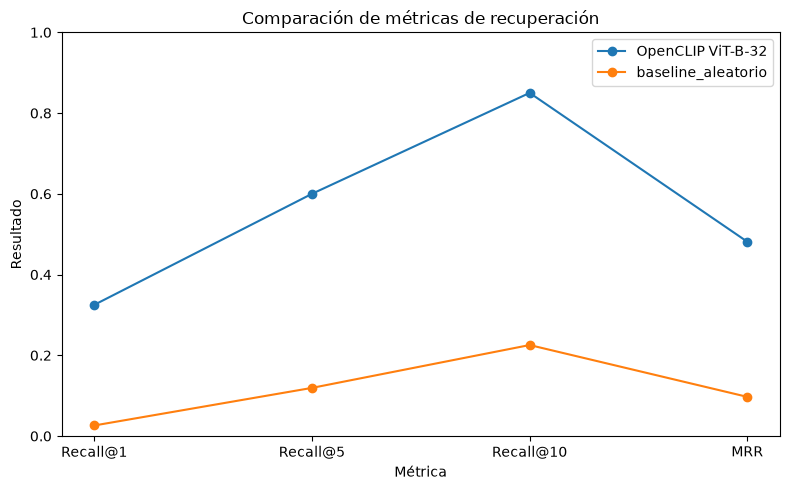

Figura guardada en: D:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-textiles-generados-evaluacion-multimodal\figures\comparacion_metricas.png


In [23]:
# ============================================================
# 21. Gráfico de métricas principales
# ============================================================

plot_metrics = ["Recall@1", "Recall@5", "Recall@10", "MRR"]

plot_df = metrics_df[metrics_df["metrica"].isin(plot_metrics)].copy()

plt.figure(figsize=(8, 5))

for modelo in plot_df["modelo"].unique():
    subset = plot_df[plot_df["modelo"] == modelo]
    plt.plot(subset["metrica"], subset["resultado"], marker="o", label=modelo)

plt.title("Comparación de métricas de recuperación")
plt.xlabel("Métrica")
plt.ylabel("Resultado")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

comparison_fig_path = FIGURES_DIR / "comparacion_metricas.png"
plt.savefig(comparison_fig_path, dpi=150)
plt.show()

print("Figura guardada en:", comparison_fig_path)

In [25]:
# ============================================================
# 22. Interpretación preliminar de resultados
# ============================================================

def get_metric_value(df, modelo_keyword, metric_name):
    subset = df[
        df["modelo"].str.contains(modelo_keyword, case=False, na=False)
        & (df["metrica"] == metric_name)
    ]

    if subset.empty:
        return None

    return float(subset.iloc[0]["resultado"])


model_recall1 = get_metric_value(metrics_df, "OpenCLIP", "Recall@1")
model_recall5 = get_metric_value(metrics_df, "OpenCLIP", "Recall@5")
model_mrr = get_metric_value(metrics_df, "OpenCLIP", "MRR")

baseline_recall1 = get_metric_value(metrics_df, "baseline", "Recall@1")
baseline_recall5 = get_metric_value(metrics_df, "baseline", "Recall@5")
baseline_mrr = get_metric_value(metrics_df, "baseline", "MRR")

print("Recall@1 modelo:", model_recall1)
print("Recall@5 modelo:", model_recall5)
print("MRR modelo:", model_mrr)
print("Recall@1 baseline:", baseline_recall1)
print("Recall@5 baseline:", baseline_recall5)
print("MRR baseline:", baseline_mrr)

if model_recall1 is not None and baseline_recall1 is not None:
    if model_recall1 > baseline_recall1:
        print("El modelo supera al baseline en Recall@1.")
    else:
        print("El modelo no supera claramente al baseline en Recall@1.")

if model_recall5 is not None and baseline_recall5 is not None:
    if model_recall5 > baseline_recall5:
        print("El modelo supera al baseline en Recall@5.")
    else:
        print("El modelo no supera claramente al baseline en Recall@5.")

Recall@1 modelo: 0.325
Recall@5 modelo: 0.6
MRR modelo: 0.4812562240391188
Recall@1 baseline: 0.026175
Recall@5 baseline: 0.1193
MRR baseline: 0.0970354305171104
El modelo supera al baseline en Recall@1.
El modelo supera al baseline en Recall@5.


# Análisis cualitativo de cinco casos

En esta sección se seleccionan cinco casos reales del experimento: dos aciertos claros, dos errores claros y un caso ambiguo. La selección se realiza a partir de los rankings generados por el modelo, no de ejemplos construidos manualmente después de la evaluación.

In [ ]:
# ============================================================
# 23. Carga de archivos para análisis de casos
# ============================================================

rankings_path = RESULTS_DIR / "rankings_imagen_texto_top10.csv"
first_rank_path = RESULTS_DIR / "primer_acierto_por_imagen.csv"

rankings_df = pd.read_csv(rankings_path)
first_rank_df = pd.read_csv(first_rank_path)
manifest = pd.read_csv(MANIFEST_PATH)

print("Rankings:", rankings_df.shape)
print("Primer acierto por imagen:", first_rank_df.shape)
print("Manifest:", manifest.shape)

first_rank_df.head()

Rankings: (400, 8)
Primer acierto por imagen: (40, 9)
Manifest: (40, 13)


,image_id,top1_text_id,top1_image_id,top1_caption,top1_score,is_top1_correct,first_correct_rank,first_correct_caption,first_correct_score
0,T001,T031_caption_1,T031,Patron textil generado con composicion horizon...,0.361577,False,2,Patron textil generado con composicion horizon...,0.361577
1,T002,T032_caption_1,T032,Patron textil generado con composicion vertica...,0.369598,False,2,Patron textil generado con composicion vertica...,0.369598
2,T003,T033_caption_1,T033,Patron textil generado con composicion central...,0.284346,False,2,Patron textil generado con composicion central...,0.284346
3,T004,T014_caption_1,T014,Patron textil generado con composicion vertica...,0.307225,False,8,Patron textil generado con composicion modular...,0.277815
4,T005,T020_caption_1,T020,Patron textil generado con composicion vertica...,0.272386,False,5,Patron textil generado con composicion reticul...,0.265400


In [ ]:
# ============================================================
# 24. Integración de resultados con atributos visuales
# ============================================================

case_base_df = first_rank_df.merge(
    manifest[
        [
            "image_id",
            "image_path",
            "paleta",
            "composicion",
            "motivo",
            "simetria",
            "nivel_ambiguedad"
        ]
    ],
    on="image_id",
    how="left"
)

case_base_df.head()

,image_id,top1_text_id,top1_image_id,top1_caption,top1_score,is_top1_correct,first_correct_rank,first_correct_caption,first_correct_score,image_path,paleta,composicion,motivo,simetria,nivel_ambiguedad
0,T001,T031_caption_1,T031,Patron textil generado con composicion horizon...,0.361577,False,2,Patron textil generado con composicion horizon...,0.361577,data/images/T001.png,rojo_negro_crema,horizontal,bandas geometricas,repetitiva,bajo
1,T002,T032_caption_1,T032,Patron textil generado con composicion vertica...,0.369598,False,2,Patron textil generado con composicion vertica...,0.369598,data/images/T002.png,azul_crema_marron,vertical,bandas geometricas,repetitiva,bajo
2,T003,T033_caption_1,T033,Patron textil generado con composicion central...,0.284346,False,2,Patron textil generado con composicion central...,0.284346,data/images/T003.png,ocre_marron_negro,central,rombos,bilateral,medio
3,T004,T014_caption_1,T014,Patron textil generado con composicion vertica...,0.307225,False,8,Patron textil generado con composicion modular...,0.277815,data/images/T004.png,blanco_negro_gris,modular,grecas escalonadas,repetitiva,medio
4,T005,T020_caption_1,T020,Patron textil generado con composicion vertica...,0.272386,False,5,Patron textil generado con composicion reticul...,0.265400,data/images/T005.png,multicolor_tierra,reticular,cuadricula geometrica,repetitiva,bajo


In [ ]:
# ============================================================
# 25. Selección automática de cinco casos
# ============================================================

# Aciertos claros: top 1 correcto
success_candidates = case_base_df[
    case_base_df["is_top1_correct"] == True
].copy()

success_cases = success_candidates.sort_values(
    by="top1_score",
    ascending=False
).head(2)

# Errores claros: el primer caption correcto aparece después del top 5
error_candidates = case_base_df[
    case_base_df["first_correct_rank"] > 5
].copy()

# Si hubiera menos de dos errores fuertes, usar errores donde top 1 sea incorrecto
if len(error_candidates) < 2:
    error_candidates = case_base_df[
        case_base_df["is_top1_correct"] == False
    ].copy()

error_cases = error_candidates.sort_values(
    by="first_correct_rank",
    ascending=False
).head(2)

# Caso ambiguo: preferir imagen con ambigüedad alta y resultado no perfecto
ambiguous_candidates = case_base_df[
    (case_base_df["nivel_ambiguedad"] == "alto")
    & (case_base_df["is_top1_correct"] == False)
].copy()

# Si no hay candidatos, elegir caso de ambigüedad alta aunque haya sido correcto
if len(ambiguous_candidates) == 0:
    ambiguous_candidates = case_base_df[
        case_base_df["nivel_ambiguedad"] == "alto"
    ].copy()

# Si todavía no hay, elegir un caso donde el correcto aparezca entre rank 2 y 5
if len(ambiguous_candidates) == 0:
    ambiguous_candidates = case_base_df[
        (case_base_df["first_correct_rank"] > 1)
        & (case_base_df["first_correct_rank"] <= 5)
    ].copy()

ambiguous_case = ambiguous_candidates.sort_values(
    by="first_correct_rank",
    ascending=True
).head(1)

selected_cases_df = pd.concat(
    [success_cases, error_cases, ambiguous_case],
    ignore_index=True
)

selected_cases_df["tipo_caso"] = [
    "acierto",
    "acierto",
    "error",
    "error",
    "ambiguo"
][:len(selected_cases_df)]

selected_cases_df[
    [
        "image_id",
        "tipo_caso",
        "top1_caption",
        "first_correct_caption",
        "first_correct_rank",
        "paleta",
        "composicion",
        "motivo",
        "simetria",
        "nivel_ambiguedad"
    ]
]

,image_id,tipo_caso,top1_caption,first_correct_caption,first_correct_rank,paleta,composicion,motivo,simetria,nivel_ambiguedad
0,T037,acierto,Patron textil generado con composicion horizon...,Patron textil generado con composicion horizon...,1,azul_crema_marron,horizontal,bandas geometricas,repetitiva,bajo
1,T032,acierto,Patron textil generado con composicion vertica...,Patron textil generado con composicion vertica...,1,azul_crema_marron,vertical,bandas geometricas,repetitiva,bajo
2,T010,error,Patron textil generado con composicion horizon...,Diseno geometrico generado con paleta multicol...,26,multicolor_tierra,modular,grecas escalonadas,repetitiva,medio
3,T040,error,Patron textil generado con composicion horizon...,Diseno geometrico generado con paleta multicol...,25,multicolor_tierra,modular,grecas escalonadas,repetitiva,medio
4,T024,ambiguo,Patron textil generado con composicion horizon...,"Patron textil generado con composicion mixta, ...",4,blanco_negro_gris,mixta,motivos geometricos combinados,asimetrica,alto


In [ ]:
# ============================================================
# 26. Construcción de tabla de casos analizados
# ============================================================

def build_error_type(row):
    if row["tipo_caso"] == "acierto":
        return "no_aplica"

    if row["tipo_caso"] == "ambiguo":
        return "error_por_ambiguedad_visual"

    if row["first_correct_rank"] > 5:
        return "error_de_alineamiento_imagen_texto"

    return "error_de_ranking"


def build_explanation(row):
    if row["tipo_caso"] == "acierto":
        return (
            "El modelo ubicó un caption correcto en la primera posición. "
            f"La salida coincide con atributos visibles como composición {row['composicion']}, "
            f"motivo {row['motivo']} y paleta {row['paleta']}."
        )

    if row["tipo_caso"] == "error":
        return (
            "El modelo ubicó como primera opción un caption asociado a otra imagen. "
            f"El primer caption correcto apareció en la posición {int(row['first_correct_rank'])}. "
            "Esto sugiere una confusión entre patrones visualmente parecidos o una asociación insuficiente "
            "entre los atributos de la imagen y el texto correspondiente."
        )

    return (
        "El caso se considera ambiguo porque la imagen presenta una lectura visual menos directa. "
        f"El nivel de ambigüedad registrado es {row['nivel_ambiguedad']}. "
        "La salida del modelo puede estar parcialmente relacionada con la imagen, pero no permite una decisión estricta sin revisión cualitativa."
    )


case_rows = []

for idx, row in selected_cases_df.iterrows():
    case_id = f"C{idx + 1:02d}"

    case_rows.append({
        "caso_id": case_id,
        "image_id": row["image_id"],
        "entrada": row["image_path"],
        "salida_modelo": row["top1_caption"],
        "resultado_esperado": row["first_correct_caption"],
        "rank_correcto": int(row["first_correct_rank"]),
        "tipo_caso": row["tipo_caso"],
        "tipo_error": build_error_type(row),
        "explicacion_breve": build_explanation(row)
    })

casos_analizados_df = pd.DataFrame(case_rows)

casos_path = RESULTS_DIR / "casos_analizados.csv"
casos_analizados_df.to_csv(
    casos_path,
    index=False,
    encoding="utf-8",
    lineterminator="\n"
)

print("Casos analizados exportados a:", casos_path)
casos_analizados_df

Casos analizados exportados a: D:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-textiles-generados-evaluacion-multimodal\results\casos_analizados.csv


,caso_id,image_id,entrada,salida_modelo,resultado_esperado,rank_correcto,tipo_caso,tipo_error,explicacion_breve
0,C01,T037,data/images/T037.png,Patron textil generado con composicion horizon...,Patron textil generado con composicion horizon...,1,acierto,no_aplica,El modelo ubicó un caption correcto en la prim...
1,C02,T032,data/images/T032.png,Patron textil generado con composicion vertica...,Patron textil generado con composicion vertica...,1,acierto,no_aplica,El modelo ubicó un caption correcto en la prim...
2,C03,T010,data/images/T010.png,Patron textil generado con composicion horizon...,Diseno geometrico generado con paleta multicol...,26,error,error_de_alineamiento_imagen_texto,El modelo ubicó como primera opción un caption...
3,C04,T040,data/images/T040.png,Patron textil generado con composicion horizon...,Diseno geometrico generado con paleta multicol...,25,error,error_de_alineamiento_imagen_texto,El modelo ubicó como primera opción un caption...
4,C05,T024,data/images/T024.png,Patron textil generado con composicion horizon...,"Patron textil generado con composicion mixta, ...",4,ambiguo,error_por_ambiguedad_visual,El caso se considera ambiguo porque la imagen ...


In [ ]:
# ============================================================
# 27. Rankings top 10 de los casos seleccionados
# ============================================================

selected_image_ids = casos_analizados_df["image_id"].tolist()

selected_rankings_df = rankings_df[
    rankings_df["image_id"].isin(selected_image_ids)
].copy()

selected_rankings_path = RESULTS_DIR / "rankings_casos_seleccionados.csv"

selected_rankings_df.to_csv(
    selected_rankings_path,
    index=False,
    encoding="utf-8",
    lineterminator="\n"
)

print("Rankings de casos seleccionados exportados a:", selected_rankings_path)

selected_rankings_df[
    [
        "image_id",
        "rank",
        "candidate_image_id",
        "caption",
        "score",
        "is_correct"
    ]
].head(50)

Rankings de casos seleccionados exportados a: D:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-textiles-generados-evaluacion-multimodal\results\rankings_casos_seleccionados.csv


,image_id,rank,candidate_image_id,caption,score,is_correct
90,T010,1,T025,Patron textil generado con composicion horizon...,0.313523,False
91,T010,2,T020,Patron textil generado con composicion vertica...,0.307310,False
92,T010,3,T035,Patron textil generado con composicion reticul...,0.293624,False
93,T010,4,T005,Patron textil generado con composicion reticul...,0.293624,False
94,T010,5,T015,Patron textil generado con composicion central...,0.292925,False
95,T010,6,T013,Patron textil generado con composicion horizon...,0.292036,False
96,T010,7,T007,Patron textil generado con composicion horizon...,0.288224,False
97,T010,8,T037,Patron textil generado con composicion horizon...,0.288224,False
98,T010,9,T038,Patron textil generado con composicion vertica...,0.286794,False
99,T010,10,T008,Patron textil generado con composicion vertica...,0.286794,False


Figura guardada en: D:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-textiles-generados-evaluacion-multimodal\figures\ejemplos_evaluados.png


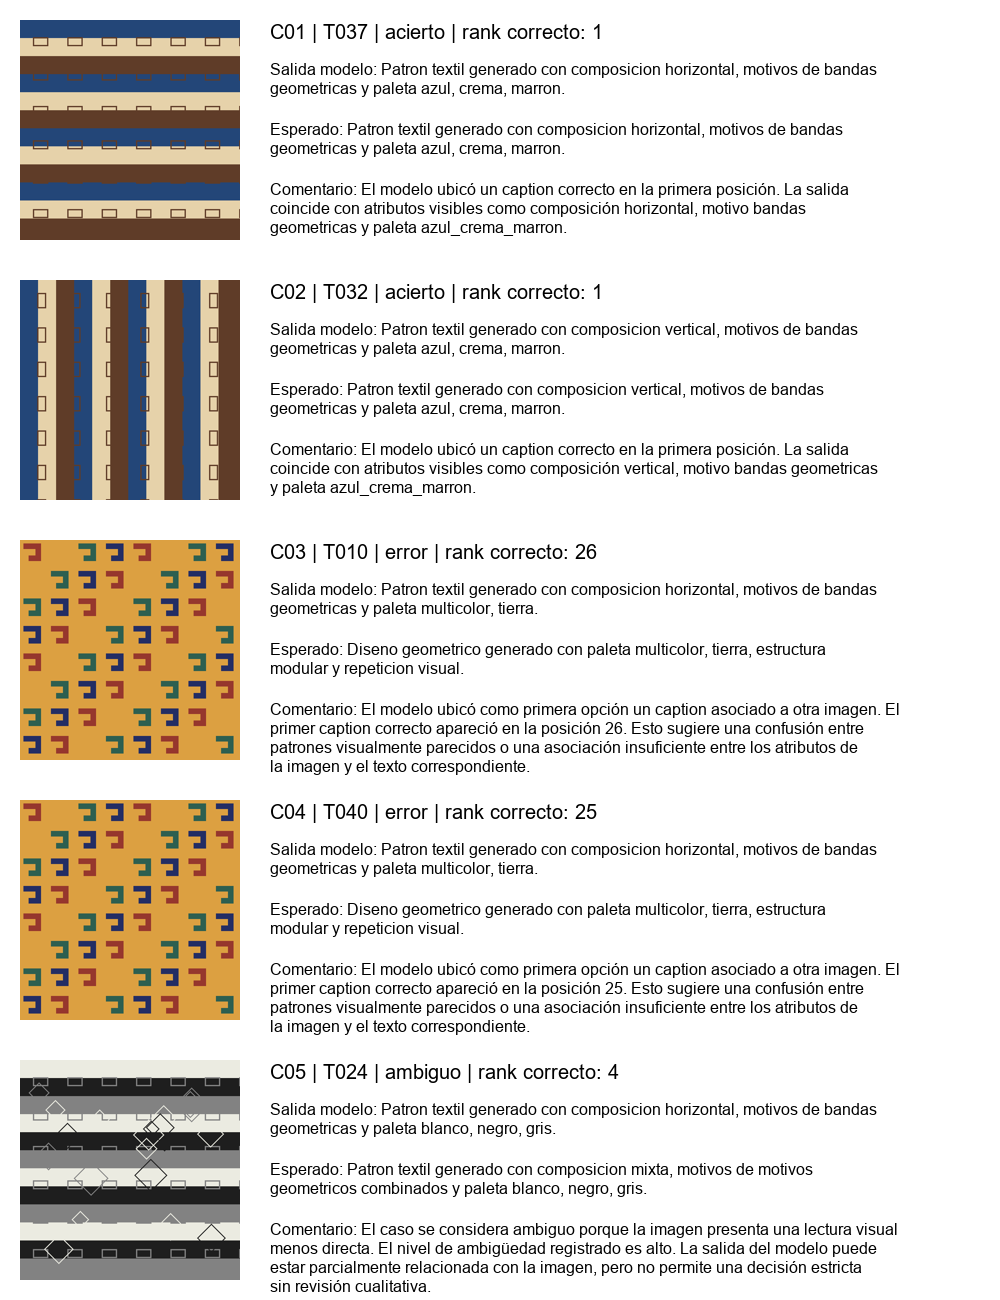

In [ ]:
# ============================================================
# 28. Figura con ejemplos evaluados
# ============================================================

from PIL import ImageDraw, ImageFont
import textwrap

def load_font(size=18):
    try:
        return ImageFont.truetype("arial.ttf", size)
    except:
        return ImageFont.load_default()


def wrap_text(text, width=58):
    return "\n".join(textwrap.wrap(str(text), width=width))


font_title = load_font(20)
font_text = load_font(16)

panel_width = 1000
panel_height = 260
thumb_size = 220

canvas = Image.new(
    "RGB",
    (panel_width, panel_height * len(casos_analizados_df)),
    color=(255, 255, 255)
)

draw = ImageDraw.Draw(canvas)

for idx, row in casos_analizados_df.iterrows():
    y0 = idx * panel_height

    image_path = BASE_DIR / row["entrada"]
    img = Image.open(image_path).convert("RGB")
    img.thumbnail((thumb_size, thumb_size))

    canvas.paste(img, (20, y0 + 20))

    title = f"{row['caso_id']} | {row['image_id']} | {row['tipo_caso']} | rank correcto: {row['rank_correcto']}"
    draw.text((270, y0 + 20), title, fill=(0, 0, 0), font=font_title)

    model_text = "Salida modelo: " + row["salida_modelo"]
    expected_text = "Esperado: " + row["resultado_esperado"]
    explanation_text = "Comentario: " + row["explicacion_breve"]

    draw.text((270, y0 + 60), wrap_text(model_text, 85), fill=(0, 0, 0), font=font_text)
    draw.text((270, y0 + 120), wrap_text(expected_text, 85), fill=(0, 0, 0), font=font_text)
    draw.text((270, y0 + 180), wrap_text(explanation_text, 85), fill=(0, 0, 0), font=font_text)

figure_path = FIGURES_DIR / "ejemplos_evaluados.png"
canvas.save(figure_path)

print("Figura guardada en:", figure_path)

canvas

In [ ]:
# ============================================================
# 29. Tabla Markdown para el reporte
# ============================================================

def df_to_markdown_table(df, columns):
    header = "| " + " | ".join(columns) + " |"
    separator = "| " + " | ".join(["---"] * len(columns)) + " |"

    rows = []
    for _, row in df.iterrows():
        values = []
        for col in columns:
            value = str(row[col]).replace("\n", " ")
            values.append(value)
        rows.append("| " + " | ".join(values) + " |")

    return "\n".join([header, separator] + rows)


report_columns = [
    "caso_id",
    "image_id",
    "tipo_caso",
    "salida_modelo",
    "resultado_esperado",
    "rank_correcto",
    "tipo_error",
    "explicacion_breve"
]

markdown_cases = df_to_markdown_table(casos_analizados_df, report_columns)

print(markdown_cases)

| caso_id | image_id | tipo_caso | salida_modelo | resultado_esperado | rank_correcto | tipo_error | explicacion_breve |
| --- | --- | --- | --- | --- | --- | --- | --- |
| C01 | T037 | acierto | Patron textil generado con composicion horizontal, motivos de bandas geometricas y paleta azul, crema, marron. | Patron textil generado con composicion horizontal, motivos de bandas geometricas y paleta azul, crema, marron. | 1 | no_aplica | El modelo ubicó un caption correcto en la primera posición. La salida coincide con atributos visibles como composición horizontal, motivo bandas geometricas y paleta azul_crema_marron. |
| C02 | T032 | acierto | Patron textil generado con composicion vertical, motivos de bandas geometricas y paleta azul, crema, marron. | Patron textil generado con composicion vertical, motivos de bandas geometricas y paleta azul, crema, marron. | 1 | no_aplica | El modelo ubicó un caption correcto en la primera posición. La salida coincide con atributos visibles como compo

# Pruebas de confiabilidad

En esta sección se realizan dos pruebas breves de confiabilidad. La primera evalúa la sensibilidad del sistema ante cambios en la redacción del texto. La segunda evalúa el comportamiento del sistema cuando las imágenes se degradan visualmente.

Estas pruebas no buscan demostrar robustez completa. Su objetivo es observar si el sistema mantiene un comportamiento razonable bajo cambios pequeños pero relevantes.

In [10]:
# ============================================================
# 30. Función auxiliar para clasificar cambios observados
# ============================================================

def clasificar_cambio(rank_original, rank_variante, score_original=None, score_variante=None):
    rank_original = int(rank_original)
    rank_variante = int(rank_variante)

    diferencia_rank = abs(rank_variante - rank_original)

    if score_original is not None and score_variante is not None:
        diferencia_score = abs(float(score_variante) - float(score_original))
    else:
        diferencia_score = 0.0

    if diferencia_rank <= 1 and diferencia_score < 0.03:
        return "bajo"

    if diferencia_rank <= 5 and diferencia_score < 0.08:
        return "medio"

    return "alto"

In [30]:
# ============================================================
# 31. Prueba 1: sensibilidad al texto
# ============================================================

def encode_text_list(text_list):
    features_list = []

    with torch.no_grad():
        tokens = tokenizer(text_list).to(DEVICE)
        features = model.encode_text(tokens)
        features = features / features.norm(dim=-1, keepdim=True)
        features_list.append(features.cpu())

    return torch.cat(features_list, dim=0).to(DEVICE)


def get_text_to_image_rank(text_feature, target_image_id):
    with torch.no_grad():
        scores = (text_feature @ image_features.T).cpu().numpy().flatten()

    sorted_indices = np.argsort(scores)[::-1]
    ordered_image_ids = [image_ids[idx] for idx in sorted_indices]

    rank = ordered_image_ids.index(target_image_id) + 1
    score = float(scores[image_ids.index(target_image_id)])

    top1_image_id = ordered_image_ids[0]
    top1_score = float(scores[sorted_indices[0]])

    return rank, score, top1_image_id, top1_score


# Selección de casos para la prueba
prompt_test_df = manifest.head(5).copy()

prompt_rows = []

for _, row in prompt_test_df.iterrows():
    image_id = row["image_id"]

    original_text = row["caption_1"]

    variant_text = (
        f"Imagen generada con motivo {row['motivo']}, "
        f"composición {row['composicion']} y paleta {row['paleta']}."
    )

    original_feature = encode_text_list([original_text])[0:1]
    variant_feature = encode_text_list([variant_text])[0:1]

    original_rank, original_score, original_top1, original_top1_score = get_text_to_image_rank(
        original_feature,
        image_id
    )

    variant_rank, variant_score, variant_top1, variant_top1_score = get_text_to_image_rank(
        variant_feature,
        image_id
    )

    cambio_observado = clasificar_cambio(
        original_rank,
        variant_rank,
        original_score,
        variant_score
    )

    prompt_rows.append({
        "prueba": "sensibilidad_al_texto",
        "image_id": image_id,
        "entrada_original": original_text,
        "variante": variant_text,
        "rank_original": original_rank,
        "rank_variante": variant_rank,
        "score_original": original_score,
        "score_variante": variant_score,
        "top1_original": original_top1,
        "top1_variante": variant_top1,
        "cambio_score": abs(variant_score - original_score),
        "cambio_rank": abs(variant_rank - original_rank),
        "cambio_observado": cambio_observado,
        "interpretacion": (
            "Evalúa si una reformulación textual con significado similar cambia de forma importante "
            "la posición de la imagen esperada."
        )
    })

prompt_sensitivity_df = pd.DataFrame(prompt_rows)

prompt_sensitivity_df

,prueba,image_id,entrada_original,variante,rank_original,rank_variante,score_original,score_variante,top1_original,top1_variante,cambio_score,cambio_rank,cambio_observado,interpretacion
0,sensibilidad_al_texto,T001,Patron textil generado con composicion horizon...,"Imagen generada con motivo bandas geometricas,...",3,4,0.361577,0.332268,T006,T036,0.029308,1,bajo,Evalúa si una reformulación textual con signif...
1,sensibilidad_al_texto,T002,Patron textil generado con composicion vertica...,"Imagen generada con motivo bandas geometricas,...",3,1,0.369598,0.368487,T012,T002,0.001111,2,medio,Evalúa si una reformulación textual con signif...
2,sensibilidad_al_texto,T003,Patron textil generado con composicion central...,"Imagen generada con motivo rombos, composición...",15,7,0.284346,0.284189,T018,T018,0.000157,8,alto,Evalúa si una reformulación textual con signif...
3,sensibilidad_al_texto,T004,Patron textil generado con composicion modular...,"Imagen generada con motivo grecas escalonadas,...",6,6,0.277815,0.245293,T014,T014,0.032522,0,medio,Evalúa si una reformulación textual con signif...
4,sensibilidad_al_texto,T005,Patron textil generado con composicion reticul...,Imagen generada con motivo cuadricula geometri...,13,11,0.265400,0.228928,T030,T030,0.036472,2,medio,Evalúa si una reformulación textual con signif...


In [31]:
# ============================================================
# 32. Prueba 2: degradación visual
# ============================================================

from PIL import ImageFilter


def create_degraded_image(image_path):
    image = Image.open(image_path).convert("RGB")

    # Reducción de resolución
    small = image.resize((96, 96))
    restored = small.resize(image.size)

    # Conversión a escala de grises y retorno a RGB
    gray = restored.convert("L").convert("RGB")

    # Desenfoque ligero
    degraded = gray.filter(ImageFilter.GaussianBlur(radius=1.2))

    return degraded


def encode_image_from_pil(image):
    image_tensor = preprocess(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        feature = model.encode_image(image_tensor)
        feature = feature / feature.norm(dim=-1, keepdim=True)

    return feature


def get_image_to_text_first_correct_rank(image_feature, target_image_id):
    with torch.no_grad():
        scores = (image_feature @ text_features.T).cpu().numpy().flatten()

    sorted_indices = np.argsort(scores)[::-1]

    top1_idx = sorted_indices[0]
    top1_candidate = texts_df.iloc[top1_idx]

    first_correct_rank = None
    first_correct_caption = None
    first_correct_score = None

    for rank_position, text_idx in enumerate(sorted_indices, start=1):
        candidate = texts_df.iloc[text_idx]

        if candidate["image_id"] == target_image_id:
            first_correct_rank = rank_position
            first_correct_caption = candidate["text"]
            first_correct_score = float(scores[text_idx])
            break

    return {
        "top1_caption": top1_candidate["text"],
        "top1_image_id": top1_candidate["image_id"],
        "top1_score": float(scores[top1_idx]),
        "first_correct_rank": first_correct_rank,
        "first_correct_caption": first_correct_caption,
        "first_correct_score": first_correct_score
    }


# Usamos los cinco casos seleccionados si existen. Si no, usamos las primeras cinco imágenes.
try:
    selected_image_ids = casos_analizados_df["image_id"].tolist()
except NameError:
    selected_image_ids = manifest.head(5)["image_id"].tolist()

visual_test_df = manifest[manifest["image_id"].isin(selected_image_ids)].copy()

visual_rows = []

for _, row in visual_test_df.iterrows():
    image_id = row["image_id"]
    image_path = BASE_DIR / row["image_path"]

    original_info = first_rank_df[first_rank_df["image_id"] == image_id].iloc[0]

    degraded_image = create_degraded_image(image_path)
    degraded_feature = encode_image_from_pil(degraded_image)

    degraded_info = get_image_to_text_first_correct_rank(
        degraded_feature,
        image_id
    )

    original_rank = int(original_info["first_correct_rank"])
    degraded_rank = int(degraded_info["first_correct_rank"])

    original_score = float(original_info["first_correct_score"])
    degraded_score = float(degraded_info["first_correct_score"])

    cambio_observado = clasificar_cambio(
        original_rank,
        degraded_rank,
        original_score,
        degraded_score
    )

    visual_rows.append({
        "prueba": "degradacion_visual",
        "image_id": image_id,
        "entrada_original": row["image_path"],
        "variante": "imagen en baja resolución, escala de grises y desenfoque ligero",
        "rank_original": original_rank,
        "rank_variante": degraded_rank,
        "score_original": original_score,
        "score_variante": degraded_score,
        "top1_original": original_info["top1_caption"],
        "top1_variante": degraded_info["top1_caption"],
        "cambio_score": abs(degraded_score - original_score),
        "cambio_rank": abs(degraded_rank - original_rank),
        "cambio_observado": cambio_observado,
        "interpretacion": (
            "Evalúa si la recuperación imagen texto se mantiene cuando la imagen pierde calidad visual."
        )
    })

visual_degradation_df = pd.DataFrame(visual_rows)

visual_degradation_df

,prueba,image_id,entrada_original,variante,rank_original,rank_variante,score_original,score_variante,top1_original,top1_variante,cambio_score,cambio_rank,cambio_observado,interpretacion
0,degradacion_visual,T010,data/images/T010.png,"imagen en baja resolución, escala de grises y ...",26,28,0.260654,0.216106,Patron textil generado con composicion horizon...,Patron textil generado con composicion central...,0.044548,2,medio,Evalúa si la recuperación imagen texto se mant...
1,degradacion_visual,T024,data/images/T024.png,"imagen en baja resolución, escala de grises y ...",4,6,0.317083,0.281385,Patron textil generado con composicion horizon...,Patron textil generado con composicion horizon...,0.035698,2,medio,Evalúa si la recuperación imagen texto se mant...
2,degradacion_visual,T032,data/images/T032.png,"imagen en baja resolución, escala de grises y ...",1,28,0.369598,0.216695,Patron textil generado con composicion vertica...,Patron textil generado con composicion vertica...,0.152903,27,alto,Evalúa si la recuperación imagen texto se mant...
3,degradacion_visual,T037,data/images/T037.png,"imagen en baja resolución, escala de grises y ...",1,21,0.371224,0.220564,Patron textil generado con composicion horizon...,Patron textil generado con composicion horizon...,0.150660,20,alto,Evalúa si la recuperación imagen texto se mant...
4,degradacion_visual,T040,data/images/T040.png,"imagen en baja resolución, escala de grises y ...",25,23,0.260654,0.216106,Patron textil generado con composicion horizon...,Patron textil generado con composicion central...,0.044548,2,medio,Evalúa si la recuperación imagen texto se mant...


In [32]:
# ============================================================
# 33. Exportación de pruebas de confiabilidad
# ============================================================

confiabilidad_df = pd.concat(
    [prompt_sensitivity_df, visual_degradation_df],
    ignore_index=True
)

confiabilidad_path = RESULTS_DIR / "pruebas_confiabilidad.csv"

confiabilidad_df.to_csv(
    confiabilidad_path,
    index=False,
    encoding="utf-8",
    lineterminator="\n"
)

print("Pruebas de confiabilidad exportadas a:", confiabilidad_path)

confiabilidad_df[
    [
        "prueba",
        "image_id",
        "rank_original",
        "rank_variante",
        "cambio_rank",
        "cambio_score",
        "cambio_observado",
        "interpretacion"
    ]
]

Pruebas de confiabilidad exportadas a: D:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-textiles-generados-evaluacion-multimodal\results\pruebas_confiabilidad.csv


,prueba,image_id,rank_original,rank_variante,cambio_rank,cambio_score,cambio_observado,interpretacion
0,sensibilidad_al_texto,T001,3,4,1,0.029308,bajo,Evalúa si una reformulación textual con signif...
1,sensibilidad_al_texto,T002,3,1,2,0.001111,medio,Evalúa si una reformulación textual con signif...
2,sensibilidad_al_texto,T003,15,7,8,0.000157,alto,Evalúa si una reformulación textual con signif...
3,sensibilidad_al_texto,T004,6,6,0,0.032522,medio,Evalúa si una reformulación textual con signif...
4,sensibilidad_al_texto,T005,13,11,2,0.036472,medio,Evalúa si una reformulación textual con signif...
5,degradacion_visual,T010,26,28,2,0.044548,medio,Evalúa si la recuperación imagen texto se mant...
6,degradacion_visual,T024,4,6,2,0.035698,medio,Evalúa si la recuperación imagen texto se mant...
7,degradacion_visual,T032,1,28,27,0.152903,alto,Evalúa si la recuperación imagen texto se mant...
8,degradacion_visual,T037,1,21,20,0.150660,alto,Evalúa si la recuperación imagen texto se mant...
9,degradacion_visual,T040,25,23,2,0.044548,medio,Evalúa si la recuperación imagen texto se mant...


In [33]:
# ============================================================
# 34. Resumen de confiabilidad por prueba
# ============================================================

resumen_confiabilidad_df = (
    confiabilidad_df
    .groupby(["prueba", "cambio_observado"])
    .size()
    .reset_index(name="cantidad")
)

resumen_confiabilidad_path = RESULTS_DIR / "resumen_confiabilidad.csv"

resumen_confiabilidad_df.to_csv(
    resumen_confiabilidad_path,
    index=False,
    encoding="utf-8",
    lineterminator="\n"
)

print("Resumen de confiabilidad exportado a:", resumen_confiabilidad_path)

resumen_confiabilidad_df

Resumen de confiabilidad exportado a: D:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-textiles-generados-evaluacion-multimodal\results\resumen_confiabilidad.csv


,prueba,cambio_observado,cantidad
0,degradacion_visual,alto,2
1,degradacion_visual,medio,3
2,sensibilidad_al_texto,alto,1
3,sensibilidad_al_texto,bajo,1
4,sensibilidad_al_texto,medio,3


In [34]:
# ============================================================
# 35. Clasificación final de confiabilidad
# ============================================================

n_altos = int((confiabilidad_df["cambio_observado"] == "alto").sum())
n_medios = int((confiabilidad_df["cambio_observado"] == "medio").sum())
n_bajos = int((confiabilidad_df["cambio_observado"] == "bajo").sum())

if n_altos >= 3:
    clasificacion_final = "No confiable para uso real"
elif n_altos >= 1 or n_medios >= 3:
    clasificacion_final = "Confiable solo en condiciones controladas"
else:
    clasificacion_final = "Parcialmente confiable"

clasificacion_confiabilidad = {
    "cambios_bajos": n_bajos,
    "cambios_medios": n_medios,
    "cambios_altos": n_altos,
    "clasificacion_final": clasificacion_final
}

clasificacion_path = RESULTS_DIR / "clasificacion_confiabilidad.json"

with open(clasificacion_path, "w", encoding="utf-8") as f:
    json.dump(clasificacion_confiabilidad, f, ensure_ascii=False, indent=2)

clasificacion_confiabilidad

{'cambios_bajos': 1,
 'cambios_medios': 6,
 'cambios_altos': 3,
 'clasificacion_final': 'No confiable para uso real'}

In [35]:
# ============================================================
# 36. Tabla Markdown de pruebas de confiabilidad
# ============================================================

confiabilidad_report_df = confiabilidad_df[
    [
        "prueba",
        "image_id",
        "entrada_original",
        "variante",
        "cambio_observado",
        "interpretacion"
    ]
].copy()

markdown_confiabilidad = df_to_markdown_table(
    confiabilidad_report_df,
    [
        "prueba",
        "image_id",
        "entrada_original",
        "variante",
        "cambio_observado",
        "interpretacion"
    ]
)

print(markdown_confiabilidad)

| prueba | image_id | entrada_original | variante | cambio_observado | interpretacion |
| --- | --- | --- | --- | --- | --- |
| sensibilidad_al_texto | T001 | Patron textil generado con composicion horizontal, motivos de bandas geometricas y paleta rojo, negro, crema. | Imagen generada con motivo bandas geometricas, composición horizontal y paleta rojo_negro_crema. | bajo | Evalúa si una reformulación textual con significado similar cambia de forma importante la posición de la imagen esperada. |
| sensibilidad_al_texto | T002 | Patron textil generado con composicion vertical, motivos de bandas geometricas y paleta azul, crema, marron. | Imagen generada con motivo bandas geometricas, composición vertical y paleta azul_crema_marron. | medio | Evalúa si una reformulación textual con significado similar cambia de forma importante la posición de la imagen esperada. |
| sensibilidad_al_texto | T003 | Patron textil generado con composicion central, motivos de rombos y paleta ocre, marron, neg

# Explicabilidad

En esta sección se explican dos casos reales del experimento usando evidencia observable. La explicación no pretende describir el funcionamiento interno completo del modelo, sino relacionar la salida obtenida con atributos visibles de la imagen y con los textos candidatos.

Se analizan un caso de acierto y un caso de error o ambigüedad. En ambos casos se identifica también el límite de la explicación.

In [36]:
# ============================================================
# 37. Selección de casos para explicabilidad
# ============================================================

# Se parte de la tabla de cinco casos analizados.
# Debe existir casos_analizados_df desde el bloque anterior.

exp_success = casos_analizados_df[
    casos_analizados_df["tipo_caso"] == "acierto"
].head(1)

exp_non_success = casos_analizados_df[
    casos_analizados_df["tipo_caso"].isin(["error", "ambiguo"])
].head(1)

exp_cases_df = pd.concat(
    [exp_success, exp_non_success],
    ignore_index=True
)

exp_cases_df = exp_cases_df.merge(
    manifest[
        [
            "image_id",
            "image_path",
            "paleta",
            "composicion",
            "motivo",
            "simetria",
            "nivel_ambiguedad"
        ]
    ],
    on="image_id",
    how="left"
)

exp_cases_df

,caso_id,image_id,entrada,salida_modelo,resultado_esperado,rank_correcto,tipo_caso,tipo_error,explicacion_breve,image_path,paleta,composicion,motivo,simetria,nivel_ambiguedad
0,C01,T037,data/images/T037.png,Patron textil generado con composicion horizon...,Patron textil generado con composicion horizon...,1,acierto,no_aplica,El modelo ubicó un caption correcto en la prim...,data/images/T037.png,azul_crema_marron,horizontal,bandas geometricas,repetitiva,bajo
1,C03,T010,data/images/T010.png,Patron textil generado con composicion horizon...,Diseno geometrico generado con paleta multicol...,26,error,error_de_alineamiento_imagen_texto,El modelo ubicó como primera opción un caption...,data/images/T010.png,multicolor_tierra,modular,grecas escalonadas,repetitiva,medio


In [37]:
# ============================================================
# 38. Construcción de tabla de explicabilidad
# ============================================================

def construir_evidencia_visual(row):
    return (
        f"Imagen con composición {row['composicion']}, "
        f"motivo {row['motivo']}, paleta {row['paleta']} "
        f"y simetría {row['simetria']}."
    )


def construir_evidencia_textual(row):
    return (
        f"Salida del modelo: {row['salida_modelo']} "
        f"Resultado esperado: {row['resultado_esperado']}"
    )


def construir_explicacion(row):
    if row["tipo_caso"] == "acierto":
        return (
            "El caso puede explicarse porque la salida del modelo coincide con atributos visuales "
            "registrados en el manifiesto, como la composición, el motivo y la paleta. "
            "La coincidencia sugiere alineamiento entre la imagen y el texto recuperado."
        )

    if row["tipo_caso"] == "error":
        return (
            "El error puede explicarse porque el modelo recuperó primero un caption asociado a otra imagen. "
            "Esto indica que algunos rasgos generales, como geometría, color o repetición, pueden haber sido "
            "más influyentes que la correspondencia específica con la imagen evaluada."
        )

    return (
        "El caso es ambiguo porque la imagen puede compartir rasgos con más de una descripción. "
        "La salida del modelo puede ser parcialmente razonable, pero no permite una decisión estricta "
        "sin revisar los atributos visuales y los captions candidatos."
    )


def construir_limite(row):
    return (
        "La explicación se basa en atributos observables y en los resultados del ranking. "
        "No permite afirmar qué regiones exactas de la imagen usó el modelo ni demuestra comprensión "
        "del significado del patrón."
    )


explicabilidad_rows = []

for idx, row in exp_cases_df.iterrows():
    explicabilidad_rows.append({
        "caso_id": row["caso_id"],
        "image_id": row["image_id"],
        "tipo_caso": row["tipo_caso"],
        "evidencia_visual": construir_evidencia_visual(row),
        "evidencia_textual": construir_evidencia_textual(row),
        "explicacion_propuesta": construir_explicacion(row),
        "limite_explicacion": construir_limite(row)
    })

explicabilidad_df = pd.DataFrame(explicabilidad_rows)

explicabilidad_path = RESULTS_DIR / "explicabilidad.csv"

explicabilidad_df.to_csv(
    explicabilidad_path,
    index=False,
    encoding="utf-8",
    lineterminator="\n"
)

print("Tabla de explicabilidad exportada a:", explicabilidad_path)

explicabilidad_df

Tabla de explicabilidad exportada a: D:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-textiles-generados-evaluacion-multimodal\results\explicabilidad.csv


,caso_id,image_id,tipo_caso,evidencia_visual,evidencia_textual,explicacion_propuesta,limite_explicacion
0,C01,T037,acierto,"Imagen con composición horizontal, motivo band...",Salida del modelo: Patron textil generado con ...,El caso puede explicarse porque la salida del ...,La explicación se basa en atributos observable...
1,C03,T010,error,"Imagen con composición modular, motivo grecas ...",Salida del modelo: Patron textil generado con ...,El error puede explicarse porque el modelo rec...,La explicación se basa en atributos observable...


Figura guardada en: D:\Documentos\000. MSC\3er Ciclo\Multimodal\mcc225-textiles-generados-evaluacion-multimodal\figures\explicabilidad_casos.png


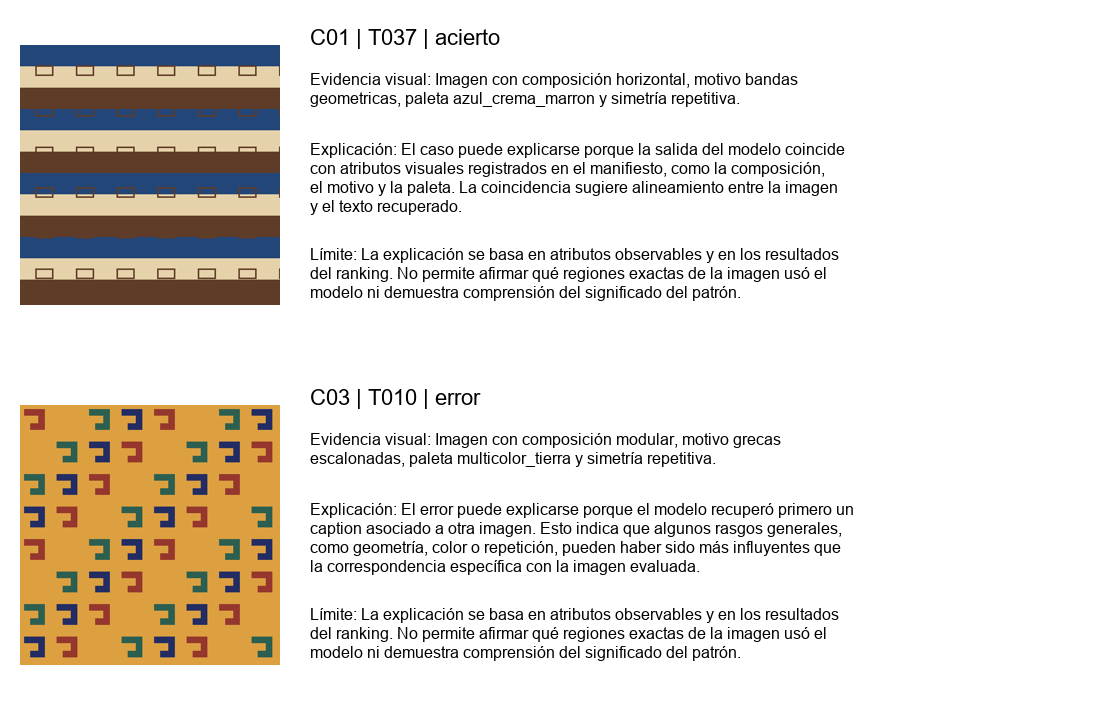

In [38]:
# ============================================================
# 39. Figura de explicabilidad
# ============================================================

from PIL import ImageDraw, ImageFont
import textwrap

def load_font_safe(size=18):
    try:
        return ImageFont.truetype("arial.ttf", size)
    except:
        return ImageFont.load_default()


def wrap_text_safe(text, width=75):
    return "\n".join(textwrap.wrap(str(text), width=width))


font_title = load_font_safe(22)
font_body = load_font_safe(16)

panel_width = 1100
panel_height = 360
thumb_size = 260

canvas = Image.new(
    "RGB",
    (panel_width, panel_height * len(explicabilidad_df)),
    color=(255, 255, 255)
)

draw = ImageDraw.Draw(canvas)

for idx, row in explicabilidad_df.iterrows():
    y0 = idx * panel_height

    image_path = BASE_DIR / exp_cases_df.loc[idx, "image_path"]
    img = Image.open(image_path).convert("RGB")
    img.thumbnail((thumb_size, thumb_size))

    canvas.paste(img, (20, y0 + 45))

    title = f"{row['caso_id']} | {row['image_id']} | {row['tipo_caso']}"
    draw.text((310, y0 + 25), title, fill=(0, 0, 0), font=font_title)

    visual_text = "Evidencia visual: " + row["evidencia_visual"]
    explanation_text = "Explicación: " + row["explicacion_propuesta"]
    limit_text = "Límite: " + row["limite_explicacion"]

    draw.text((310, y0 + 70), wrap_text_safe(visual_text), fill=(0, 0, 0), font=font_body)
    draw.text((310, y0 + 140), wrap_text_safe(explanation_text), fill=(0, 0, 0), font=font_body)
    draw.text((310, y0 + 245), wrap_text_safe(limit_text), fill=(0, 0, 0), font=font_body)

figure_explain_path = FIGURES_DIR / "explicabilidad_casos.png"

canvas.save(figure_explain_path)

print("Figura guardada en:", figure_explain_path)

canvas

In [39]:
# ============================================================
# 40. Respuestas breves sobre explicabilidad
# ============================================================

respuestas_explicabilidad = {
    "pregunta_1": "¿La explicación se basa en evidencia observable o solo racionaliza la salida después de verla?",
    "respuesta_1": (
        "La explicación se basa en evidencia observable, porque utiliza atributos registrados en el manifiesto, "
        "la imagen evaluada, la salida del modelo y el resultado esperado. Sin embargo, sigue siendo una "
        "explicación limitada, ya que no muestra las regiones exactas de atención del modelo."
    ),
    "pregunta_2": "¿La explicación ayuda a detectar un error del sistema?",
    "respuesta_2": (
        "Sí. En los casos de error o ambigüedad, la explicación permite observar si el modelo confundió "
        "atributos visuales generales, como color, composición o repetición geométrica, con una correspondencia "
        "correcta entre imagen y texto."
    )
}

respuestas_explicabilidad_path = RESULTS_DIR / "respuestas_explicabilidad.json"

with open(respuestas_explicabilidad_path, "w", encoding="utf-8") as f:
    json.dump(respuestas_explicabilidad, f, ensure_ascii=False, indent=2)

respuestas_explicabilidad

{'pregunta_1': '¿La explicación se basa en evidencia observable o solo racionaliza la salida después de verla?',
 'respuesta_1': 'La explicación se basa en evidencia observable, porque utiliza atributos registrados en el manifiesto, la imagen evaluada, la salida del modelo y el resultado esperado. Sin embargo, sigue siendo una explicación limitada, ya que no muestra las regiones exactas de atención del modelo.',
 'pregunta_2': '¿La explicación ayuda a detectar un error del sistema?',
 'respuesta_2': 'Sí. En los casos de error o ambigüedad, la explicación permite observar si el modelo confundió atributos visuales generales, como color, composición o repetición geométrica, con una correspondencia correcta entre imagen y texto.'}

In [40]:
# ============================================================
# 41. Tabla Markdown de explicabilidad para el reporte
# ============================================================

explicabilidad_report_columns = [
    "caso_id",
    "image_id",
    "tipo_caso",
    "evidencia_visual",
    "explicacion_propuesta",
    "limite_explicacion"
]

markdown_explicabilidad = df_to_markdown_table(
    explicabilidad_df,
    explicabilidad_report_columns
)

print(markdown_explicabilidad)

| caso_id | image_id | tipo_caso | evidencia_visual | explicacion_propuesta | limite_explicacion |
| --- | --- | --- | --- | --- | --- |
| C01 | T037 | acierto | Imagen con composición horizontal, motivo bandas geometricas, paleta azul_crema_marron y simetría repetitiva. | El caso puede explicarse porque la salida del modelo coincide con atributos visuales registrados en el manifiesto, como la composición, el motivo y la paleta. La coincidencia sugiere alineamiento entre la imagen y el texto recuperado. | La explicación se basa en atributos observables y en los resultados del ranking. No permite afirmar qué regiones exactas de la imagen usó el modelo ni demuestra comprensión del significado del patrón. |
| C03 | T010 | error | Imagen con composición modular, motivo grecas escalonadas, paleta multicolor_tierra y simetría repetitiva. | El error puede explicarse porque el modelo recuperó primero un caption asociado a otra imagen. Esto indica que algunos rasgos generales, como geometría, c